#Exploratory Data Analysis (EDA)


importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression#logistic regression
from sklearn.neighbors import KNeighborsClassifier#knn
from sklearn.naive_bayes import GaussianNB #naive bayes
from sklearn.tree import DecisionTreeClassifier #decision Tree
from sklearn.svm import SVC #svm
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

importing dataset

In [ ]:
churn_data=pd.read_csv("/content/customer_churn_Training_data.csv")

In [ ]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
churn_data.size

118314

In [ ]:
churn_data.shape

(5634, 21)

In [ ]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [ ]:
churn_data.nunique() #checking unique values

,0
customerID,5634
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
churn_data['TotalCharges'].dtype  #total charges is in object datatype
churn_data['TotalCharges']=pd.to_numeric(churn_data['TotalCharges'],errors='coerce')
churn_data['TotalCharges'].isna().sum()

np.int64(290)

In [ ]:
churn_data['MultipleLines'].value_counts()
#"no phone service" come under the column no , so we can merge the column to avoid redundant information

,count
MultipleLines,
No,2701
Yes,2380
No phone service,553


In [ ]:
churn_data['MultipleLines']=churn_data['MultipleLines'].replace('No phone service','No')

In [ ]:
churn_data['InternetService'].value_counts()#InternetService contains distinct values
churn_data['OnlineSecurity'].value_counts()

,count
OnlineSecurity,
No,2720
Yes,1574
No internet service,1171


In [ ]:
churn_data['DeviceProtection'].value_counts()

,count
DeviceProtection,
No,2485
Yes,1946
No internet service,1203


In [ ]:
churn_data['OnlineBackup'].value_counts()

,count
OnlineBackup,
No,2459
Yes,1972
No internet service,1203


In [ ]:
churn_data['TechSupport'].value_counts()

,count
TechSupport,
No,2782
Yes,1649
No internet service,1203


In [ ]:
churn_data['StreamingTV'].value_counts()

,count
StreamingTV,
No,2244
Yes,2187
No internet service,1203


In [ ]:
churn_data['StreamingMovies'].value_counts()

,count
StreamingMovies,
No,2232
Yes,2199
No internet service,1203


In [ ]:
churn_data['Contract'].value_counts()#distinct values
churn_data['PaymentMethod'].value_counts() #distinct


,count
PaymentMethod,
Electronic check,1892
Mailed check,1278
Bank transfer (automatic),1248
Credit card (automatic),1216


In [ ]:
internet_dependent_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
for col in internet_dependent_cols:
    churn_data[col] = churn_data[col].replace('No internet service', 'No')
churn_data['StreamingMovies'].value_counts()

,count
StreamingMovies,
No,3435
Yes,2199


In [ ]:
churn_data=churn_data.drop('customerID',axis=1)  #dropping irrelevent customerID column

checking for null values

In [ ]:
churn_data.isnull().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


Checking for duplicate values

In [ ]:
churn_data.duplicated().sum()

np.int64(8)

In [ ]:
churn_data=churn_data.drop_duplicates()

Handling Null values


In [ ]:
churn_data= churn_data.dropna(subset=['gender'])


/tmp/ipython-input-990219962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=churn_data, palette='viridis')


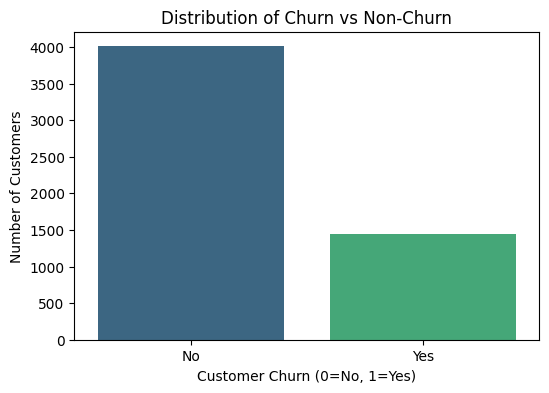

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=churn_data, palette='viridis')
plt.title('Distribution of Churn vs Non-Churn')
plt.xlabel('Customer Churn (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.show()
#dataset is imbalanced,the model is seeing many more "Non-Churn"  than "Churn".

In [ ]:
categorical=churn_data.select_dtypes(['object','category']).columns
numerical=churn_data.select_dtypes(['int64','float64']).columns

In [ ]:
print(numerical)
print(categorical)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

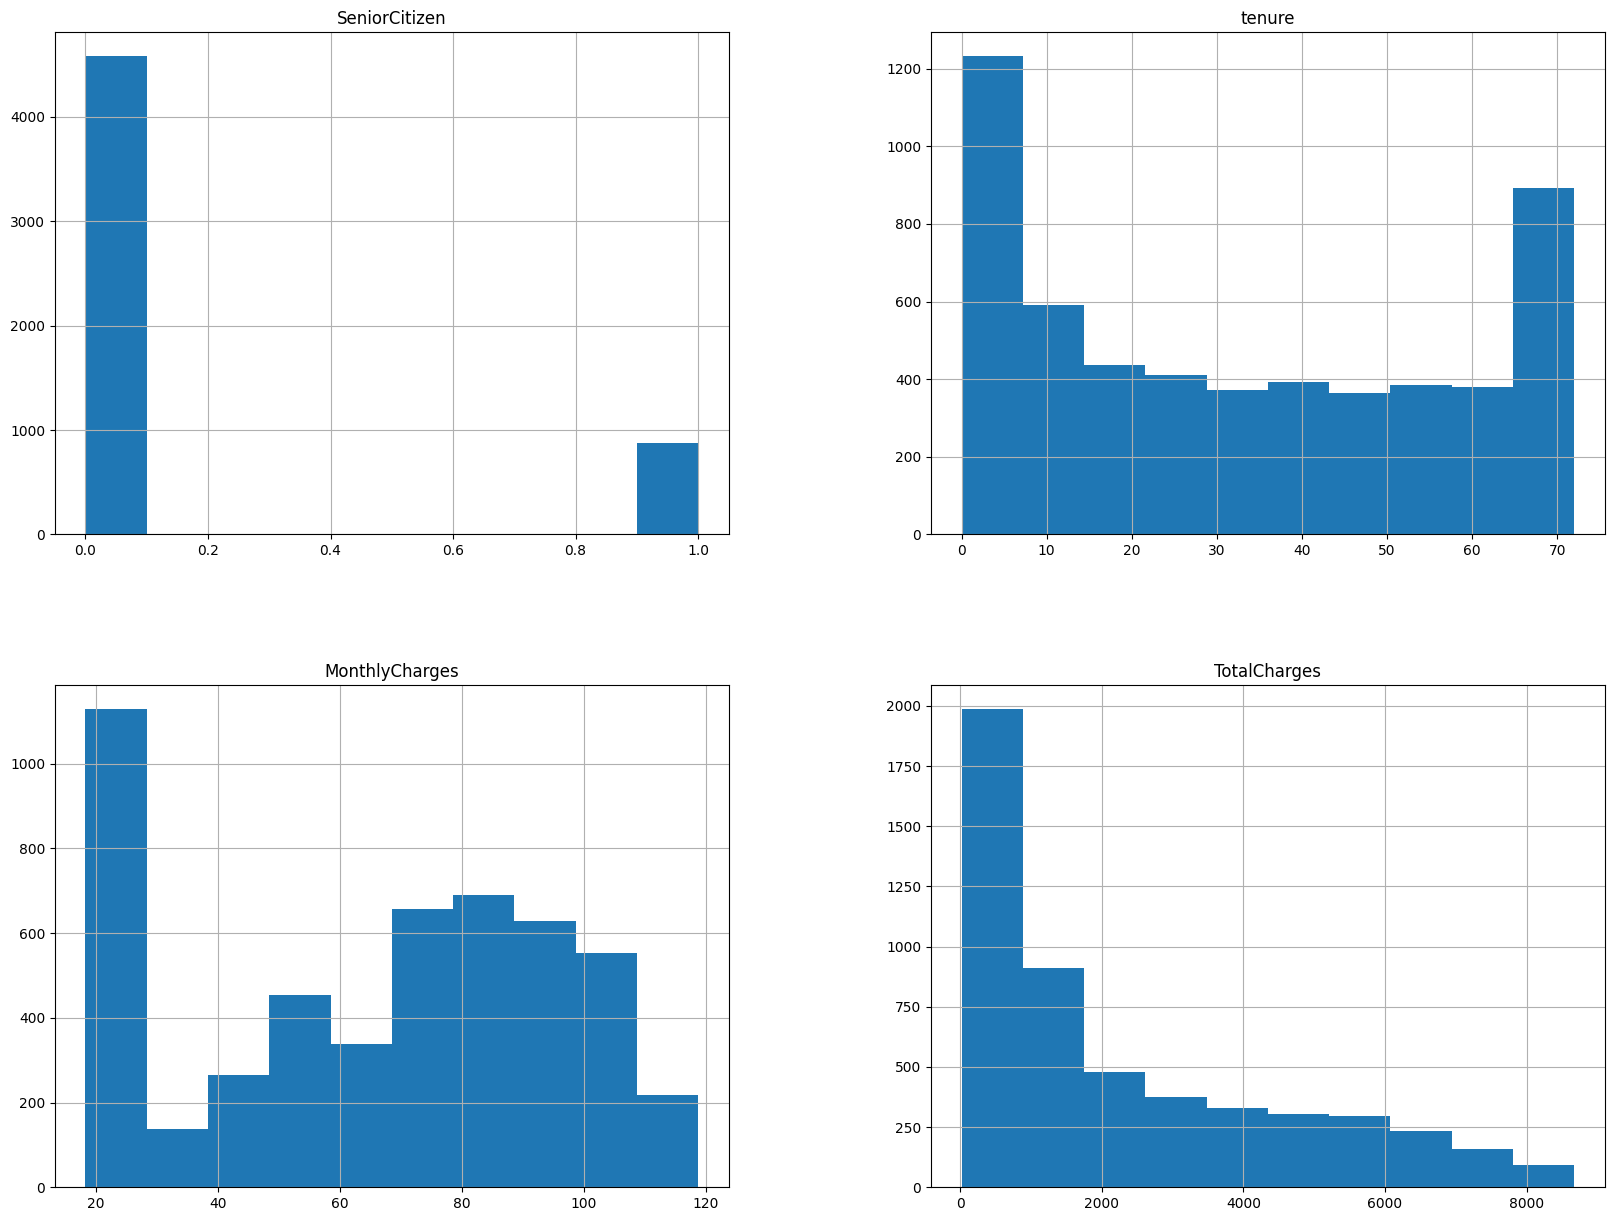

In [ ]:
#histogram
freqgraph=churn_data.select_dtypes(include='number')
freqgraph.hist(figsize=(20,15))

In [ ]:
churn_data['TotalCharges']=churn_data['TotalCharges'].fillna(churn_data['TotalCharges'].median())
#filled with median

In [ ]:
churn_data['MonthlyCharges']=churn_data['MonthlyCharges'].fillna(churn_data['MonthlyCharges'].median())
#filled with median

In [ ]:
mode_online_security= churn_data['OnlineSecurity'].mode()[0]
mode_online_security
churn_data['OnlineSecurity'].fillna(mode_online_security,inplace=True)
#filled with mode

/tmp/ipython-input-3265608635.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  churn_data['OnlineSecurity'].fillna(mode_online_security,inplace=True)


In [ ]:
churn_data['Churn'] = churn_data['Churn'].map({'Yes': 1, 'No': 0})
#converting target column from yes/no to 0/1

In [ ]:
churn_data.isnull().sum()
#null values handled

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


##Checking For Outliers

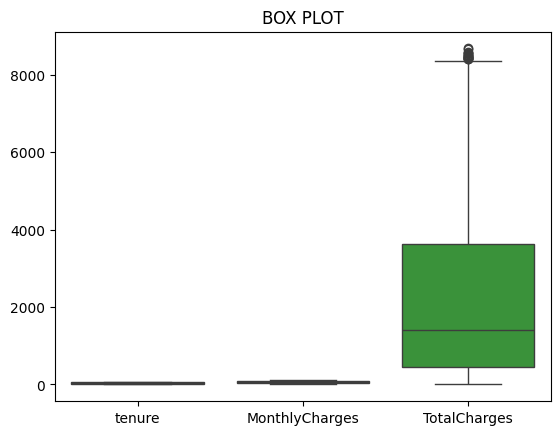

In [ ]:
sns.boxplot(data=churn_data[['tenure', 'MonthlyCharges', 'TotalCharges']])
plt.title("BOX PLOT")
plt.show()
#TotalCharges column shows outliers

###Handling Outliers

IQR Method

In [ ]:
q1=np.percentile(churn_data['TotalCharges'],25)
q3=np.percentile(churn_data['TotalCharges'],75)
iqr=q3-q1
print(q1,q3,iqr)


452.2 3623.95 3171.75


In [ ]:
up_val=q3+(1.5*iqr)
low_val=q1-(1.5*iqr)
print(up_val,low_val)

8381.575 -4305.425


In [ ]:
for x in churn_data['TotalCharges']:
  if x > up_val or x <low_val:
    print(x)

8496.7
8476.5
8404.9
8425.15
8670.1
8468.2
8594.4
8399.15
8456.75
8436.25
8477.6
8425.3
8543.25
8672.45
8564.75
8529.5
8424.9


In [ ]:
churn_data["TotalCharges"]=churn_data['TotalCharges'].clip(lower=low_val,upper=up_val)

In [ ]:
trn1=churn_data.select_dtypes(include=['number'])
corr=trn1.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.020826,0.204950,0.102177,0.152462
tenure,0.020826,1.000000,0.229976,0.796700,-0.359027
MonthlyCharges,0.204950,0.229976,1.000000,0.606428,0.190930
TotalCharges,0.102177,0.796700,0.606428,1.000000,-0.198282
Churn,0.152462,-0.359027,0.190930,-0.198282,1.000000


<Axes: >

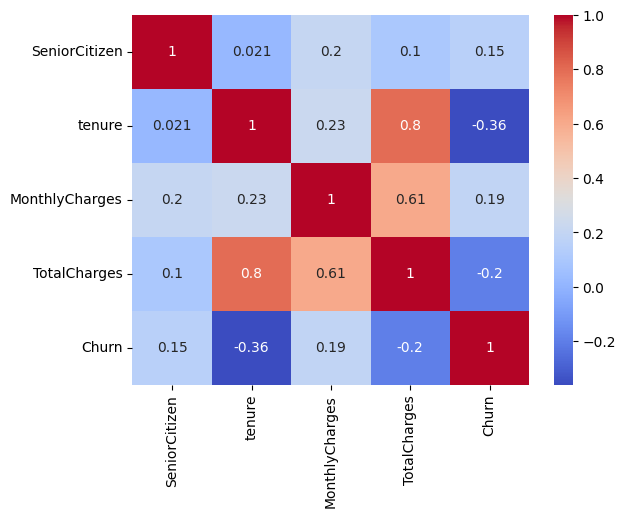

In [ ]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

#Feature Engineering

In [ ]:
churn_data['CLV'] =churn_data['tenure'] * churn_data['MonthlyCharges']

In [ ]:
# Create a numeric mapping for Contract if not already done
# Month-to-month: 1, One year: 12, Two year: 24
churn_data['Contract_Months'] = churn_data['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

# Interaction Feature
churn_data['Tenure_Contract_Interaction'] = churn_data['tenure'] * churn_data['Contract_Months']

#Encoding

In [ ]:
churn_data.dtypes.value_counts()

,count
object,15
int64,5
float64,3


In [ ]:
churn_data.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,2
InternetService,3
OnlineSecurity,2
OnlineBackup,2


In [ ]:
onehot_col=['gender','PaymentMethod','Contract','StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','InternetService','MultipleLines']
le_cols=['Partner','Dependents','PhoneService','PaperlessBilling']

In [ ]:
churn_data= pd.get_dummies(churn_data, columns= onehot_col, drop_first=True,dtype=int)
#one-hot encoding

In [ ]:

le= LabelEncoder()
# houseprice['Waterfront View']=le.fit_transform(houseprice['Waterfront View'])
# houseprice
for col in le_cols:
  if col in churn_data.columns:
    churn_data[col]=le.fit_transform(churn_data[col])
churn_data.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,CLV,...,Contract_Two year,StreamingMovies_Yes,StreamingTV_Yes,TechSupport_Yes,DeviceProtection_Yes,OnlineBackup_Yes,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,MultipleLines_Yes
0,0,0,0,35,1,0,20.75,700.45,0,726.25,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,28,0,1,35.75,961.40,0,1001.00,...,0,0,0,1,1,0,0,0,0,0
2,0,0,0,56,1,0,98.60,5581.05,0,5521.60,...,0,1,1,0,0,1,0,1,0,1
3,0,1,0,39,1,1,20.45,790.00,0,797.55,...,1,0,0,0,0,0,0,0,1,0
4,0,1,1,43,0,1,51.25,2151.60,0,2203.75,...,0,0,1,1,0,1,0,0,0,0


In [ ]:
churn_data.shape

(5457, 27)

##Feature Selection

In [ ]:
#If a feature has the same value for 99% of your customers it provides no predictive power. This removes features that have the same value in more than 99% of samples
selector = VarianceThreshold(threshold=0.01)
selector.fit(churn_data)

# Get the remaining columns
selected_cols = churn_data.columns[selector.get_support()]
churn_data = churn_data[selected_cols]

###2. Check for Multi-Collinearity (Correlation)

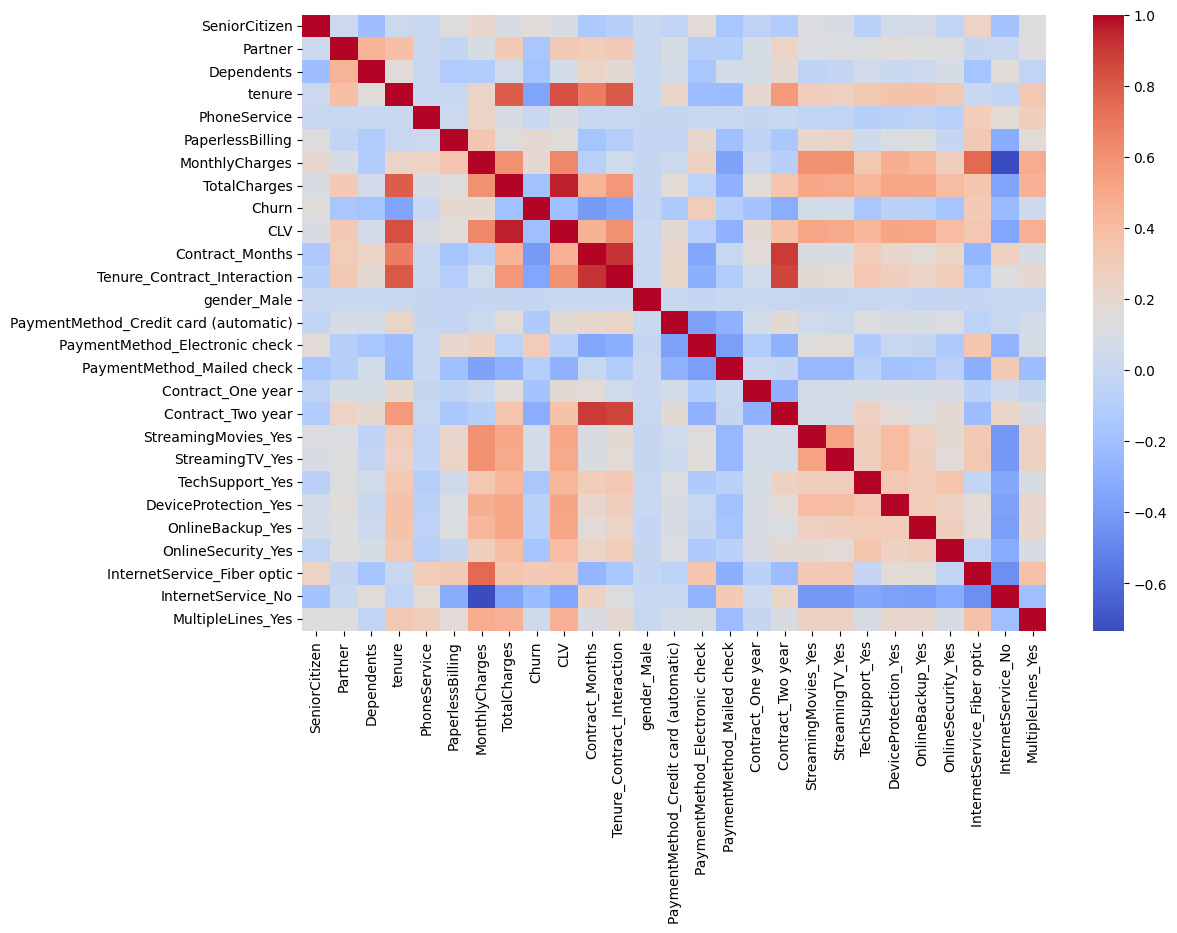

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = churn_data.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

In [ ]:

print(correlation_matrix['tenure'].sort_values(ascending=False))

tenure                                   1.000000
CLV                                      0.832820
Tenure_Contract_Interaction              0.806249
TotalCharges                             0.796700
Contract_Months                          0.675271
Contract_Two year                        0.565963
Partner                                  0.380301
OnlineBackup_Yes                         0.361391
DeviceProtection_Yes                     0.357484
MultipleLines_Yes                        0.326809
TechSupport_Yes                          0.326210
OnlineSecurity_Yes                       0.320032
StreamingMovies_Yes                      0.282754
StreamingTV_Yes                          0.273161
PaymentMethod_Credit card (automatic)    0.232784
MonthlyCharges                           0.229976
Contract_One year                        0.196493
Dependents                               0.154001
SeniorCitizen                            0.020826
gender_Male                              0.011393


In [ ]:
service_cols = [
    'MultipleLines_Yes','OnlineSecurity_Yes','OnlineBackup_Yes',
    'DeviceProtection_Yes','TechSupport_Yes',
    'StreamingTV_Yes','StreamingMovies_Yes'
]

churn_data['TotalServices'] = churn_data[service_cols].sum(axis=1)
numerical=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges','TotalServices']

#Scaling

In [ ]:
sscaler = StandardScaler()
churn_data[numerical] = sscaler.fit_transform(churn_data[numerical])

Correlation

In [ ]:
corr = churn_data.corr()['Churn'].sort_values(ascending=False)
corr


,Churn
Churn,1.000000
InternetService_Fiber optic,0.311181
PaymentMethod_Electronic check,0.300853
MonthlyCharges,0.190930
PaperlessBilling,0.189714
SeniorCitizen,0.152462
StreamingTV_Yes,0.061100
StreamingMovies_Yes,0.059483
MultipleLines_Yes,0.042416
PhoneService,0.010604


In [ ]:
# Create the correlation matrix
corr_matrix = churn_data.corr().abs()

# Select the upper triangle (to avoid duplicate pairs like A-B and B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.85
high_corr = [(column, row, upper[column][row])
             for column in upper.columns
             for row in upper.index
             if upper[column][row] > 0.85]

print("Highly Correlated Pairs (> 0.85):")
for pair in high_corr:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

Highly Correlated Pairs (> 0.85):
CLV & TotalCharges: 0.96
Tenure_Contract_Interaction & Contract_Months: 0.91
Contract_Two year & Contract_Months: 0.90
Contract_Two year & Tenure_Contract_Interaction: 0.87


In [ ]:
# List of columns to drop based on your high correlation results
to_drop = ['TotalCharges', 'Contract_Months', 'Contract_Two year']

# Update your dataframe
churn_data_final = churn_data.drop(columns=to_drop)

print(f"Features remaining: {len(churn_data_final.columns)}")
print(churn_data_final.columns)

Features remaining: 25
Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'Churn', 'CLV',
       'Tenure_Contract_Interaction', 'gender_Male',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_One year', 'StreamingMovies_Yes', 'StreamingTV_Yes',
       'TechSupport_Yes', 'DeviceProtection_Yes', 'OnlineBackup_Yes',
       'OnlineSecurity_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'MultipleLines_Yes', 'TotalServices'],
      dtype='object')


In [ ]:
churn_data_final.shape

(5457, 25)

#Training and Testing Data split

In [ ]:
X = churn_data_final.drop('Churn', axis=1)  # X - features
y = churn_data_final['Churn']  # Y - target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(4365, 24)
(1092, 24)
(4365,)
(1092,)


In [ ]:
y_train.head()

,Churn
776,1
2575,1
1070,0
3005,0
2550,1


#Logistic Regression

In [ ]:
#initializing the ML model
log_reg_model=LogisticRegression(max_iter=1000)
#training model
log_reg_model.fit(X_train,y_train)
#predict using the model and test features
y_pred_log_reg=log_reg_model.predict(X_test)
#Evaluating ML Model
Acc_log_reg=accuracy_score(y_test,y_pred_log_reg)
prec_log_reg=precision_score(y_test,y_pred_log_reg)
Rec_log_reg=recall_score(y_test,y_pred_log_reg)
f1_log_reg=f1_score(y_test,y_pred_log_reg)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Accuracy Score : ",Acc_log_reg)
print("Precision Score : ",prec_log_reg)
print("Recall Score : ",Rec_log_reg)
print("f1 Score : ",f1_log_reg)

Accuracy Score :  0.804945054945055
Precision Score :  0.6666666666666666
Recall Score :  0.5752508361204013
f1 Score :  0.6175942549371634


#Decision Tree


In [ ]:
d_model=DecisionTreeClassifier()
d_model.fit(X_train,y_train)
#predict using trained Ml model
y_pred_dtree=d_model.predict(X_test)

In [ ]:
#evaluate ml model
Acc_dtree=accuracy_score(y_test,y_pred_dtree)
prec_dtree=precision_score(y_test,y_pred_dtree)
rec_dtree=recall_score(y_test,y_pred_dtree)
f1_dtree=f1_score(y_test,y_pred_dtree)

In [ ]:
print("Accuracy:",Acc_dtree)
print("Precision: ",prec_dtree)
print("Recall:",rec_dtree)
print("f1 score:",f1_dtree)

Accuracy: 0.75
Precision:  0.5454545454545454
Recall: 0.5217391304347826
f1 score: 0.5333333333333333


#Naive Bayes

In [ ]:
#initializing the model
nb_model=GaussianNB()
#training model
nb_model.fit(X_train,y_train)
#predict using trained Ml model
y_pred_nb=nb_model.predict(X_test)

In [ ]:
#evaluate ml model
Acc_nb=accuracy_score(y_test,y_pred_nb)
prec_nb=precision_score(y_test,y_pred_nb)
rec_nb=recall_score(y_test,y_pred_nb)
f1_nb=f1_score(y_test,y_pred_nb)

In [ ]:
print("Accuracy:",Acc_nb)
print("Precision: ",prec_nb)
print("Recall:",rec_nb)
print("f1 score:",f1_nb)

Accuracy: 0.7582417582417582
Precision:  0.5386313465783664
Recall: 0.8160535117056856
f1 score: 0.648936170212766


#KNN

In [ ]:
accuracy_list = []
neighbors_range = np.arange(1,20)

for k in neighbors_range:
  classifier = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=2)  # initialising classifier for iteration using Euclidian p=2
  #Training the ML model
  classifier.fit(X_train, y_train)
  y_pred_knn=classifier.predict(X_test)  #predict using trained ML model
  acc = accuracy_score(y_test,y_pred_knn)  # evaluate the ML model
  accuracy_list.append(acc)

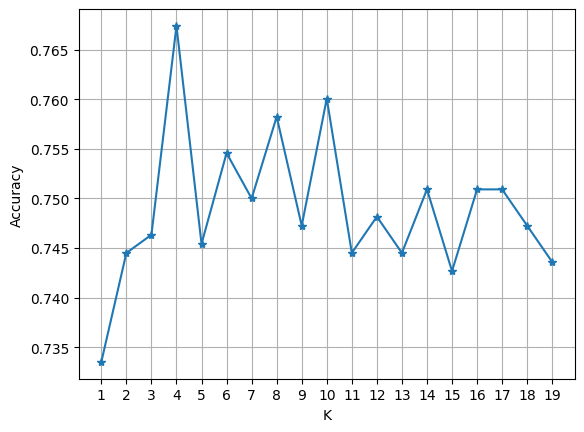

In [ ]:
plt.plot(neighbors_range, accuracy_list,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.grid()

In [ ]:
classifier_knn = KNeighborsClassifier(n_neighbors=12, metric='euclidean')
classifier_knn.fit(X_train,y_train)
y_pred_knn_eu = classifier_knn.predict(X_test)
acc_knn=accuracy_score(y_test,y_pred_knn_eu)
prec_knn=precision_score(y_test,y_pred_knn_eu)
rec_knn=recall_score(y_test,y_pred_knn_eu)
f1_knn=f1_score(y_test,y_pred_knn_eu)


In [ ]:
print('Accuracy:',acc_knn)
print('Precision:',prec_knn)
print('Recall:',rec_knn)
print('F1 Score:',f1_knn)

Accuracy: 0.7481684981684982
Precision: 0.5697674418604651
Recall: 0.3277591973244147
F1 Score: 0.416135881104034


#SVM

In [ ]:
# # create SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True)
# # train model
svm_model.fit(X_train, y_train)
#  predict using trained ML model
y_pred_svm = svm_model.predict(X_test)

In [ ]:
# Updated model with balanced weights


In [ ]:
Acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

In [ ]:
print("Accuracy:", Acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)
print("F1 score:", f1_svm)

Accuracy: 0.6336996336996337
Precision: 0.4209702660406886
Recall: 0.8996655518394648
F1 score: 0.5735607675906184


##Model comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Decision Tree','Logistic Regression','Naive Bayes','SVM','KNN'],
    'Accuracy': [Acc_dtree,Acc_log_reg,Acc_nb,Acc_svm,acc_knn],
    'Precision': [prec_dtree,prec_log_reg,prec_nb,prec_svm,prec_knn],
    'Recall': [rec_dtree,Rec_log_reg,rec_nb,rec_svm,rec_knn],
    'F1 Score': [f1_dtree,f1_log_reg,f1_nb,f1_svm,f1_knn]
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.750000,0.545455,0.521739,0.533333
1,Logistic Regression,0.804945,0.666667,0.575251,0.617594
2,Naive Bayes,0.758242,0.538631,0.816054,0.648936
3,SVM,0.633700,0.420970,0.899666,0.573561
4,KNN,0.748168,0.569767,0.327759,0.416136


# **comparison Summary**
***Highest accuracy***- Logistic Regression

***Highest precision***:Logistic Regression

***Highest recall***: SVM

***best F1 score***: Naive Bayes

***Most balanced***: Naive Bayes/Logistic Regression

Choosing Logistic Regression

#Load  Training data

In [ ]:
filePath='/content/customer_churn_Testing_data.csv'
churn_test=pd.read_csv(filePath)

In [ ]:
churn_test.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
churn_test.shape #same shape as train data

(1409, 21)

In [ ]:
churn_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
churn_test=churn_test.drop('customerID',axis=1)

handling duplicates

In [ ]:
churn_test.duplicated().sum()

np.int64(2)

In [ ]:
churn_test=churn_test.drop_duplicates()

Checking missing values

In [ ]:
churn_test.isnull().sum()
#no null values found

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
churn_test['TotalCharges'] = pd.to_numeric(churn_test['TotalCharges'], errors='coerce')

In [ ]:
churn_test.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [ ]:
churn_test= churn_test.dropna(subset=['gender'])


In [ ]:
churn_test['MultipleLines']=churn_test['MultipleLines'].replace('No phone service','No')
internet_dependent_col = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
for col in internet_dependent_col:
    churn_test[col] = churn_test[col].replace('No internet service', 'No')
churn_test['StreamingMovies'].value_counts()

,count
StreamingMovies,
No,874
Yes,533


In [ ]:
churn_test['Churn'] = churn_test['Churn'].map({'Yes': 1, 'No': 0})
#converting target column from yes/no to 0/1

Feature engineering

In [ ]:
churn_test['CLV'] =churn_test['tenure'] * churn_test['MonthlyCharges']
# Create a numeric mapping for Contract if not already done
# Month-to-month: 1, One year: 12, Two year: 24
churn_test['Contract_Months'] = churn_test['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

# Interaction Feature
churn_test['Tenure_Contract_Interaction'] = churn_test['tenure'] * churn_test['Contract_Months']

In [ ]:
churn_test['CLV'] =churn_test['tenure'] * churn_test['MonthlyCharges']

In [ ]:
churn_test.dtypes.value_counts()

,count
object,15
int64,5
float64,3


In [ ]:
onehot_col_test=['gender','PaymentMethod','Contract','StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','InternetService','MultipleLines']
le_cols_test=['Partner','Dependents','PhoneService','PaperlessBilling']

In [ ]:
churn_test= pd.get_dummies(churn_test, columns= onehot_col_test, drop_first=True,dtype=int)
#one-hot encoding

In [ ]:
le= LabelEncoder()
# houseprice['Waterfront View']=le.fit_transform(houseprice['Waterfront View'])
# houseprice
for col in le_cols_test:
  if col in churn_test.columns:
    churn_test[col]=le.fit_transform(churn_test[col])
churn_test.head()
churn_test.shape

(1407, 27)

Feature selection

In [ ]:
#If a feature has the same value for 99% of your customers it provides no predictive power.
# This removes features that have the same value in more than 99% of samples
selector = VarianceThreshold(threshold=0.01)
selector.fit(churn_test)

# Get the remaining columns
selected_cols = churn_test.columns[selector.get_support()]
churn_test = churn_test[selected_cols]

In [ ]:
service_cols = [
    'MultipleLines_Yes','OnlineSecurity_Yes','OnlineBackup_Yes',
    'DeviceProtection_Yes','TechSupport_Yes',
    'StreamingTV_Yes','StreamingMovies_Yes'
]

churn_test['TotalServices'] = churn_test[service_cols].sum(axis=1)
numericals=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges','TotalServices']

scaling

In [ ]:
sscaler = StandardScaler()
churn_test[numerical] = sscaler.fit_transform(churn_test[numerical])

In [ ]:
corr = churn_data.corr()['Churn'].sort_values(ascending=False)


In [ ]:
# Create the correlation matrix
corr_matrix = churn_test.corr().abs()

# Select the upper triangle (to avoid duplicate pairs like A-B and B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.85
high_corr = [(column, row, upper[column][row])
             for column in upper.columns
             for row in upper.index
             if upper[column][row] > 0.85]

print("Highly Correlated Pairs (> 0.85):")
for pair in high_corr:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

Highly Correlated Pairs (> 0.85):
CLV & TotalCharges: 1.00
Tenure_Contract_Interaction & Contract_Months: 0.90
Contract_Two year & Contract_Months: 0.89
Contract_Two year & Tenure_Contract_Interaction: 0.85


In [ ]:
# List of columns to drop based on your high correlation results
to_drop = ['TotalCharges', 'Contract_Months', 'Contract_Two year']

# Update your dataframe
churn_test_final = churn_test.drop(columns=to_drop)

print(f"Features remaining: {len(churn_data_final.columns)}")
print(churn_test_final.columns)

Features remaining: 25
Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'Churn', 'CLV',
       'Tenure_Contract_Interaction', 'gender_Male',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_One year', 'StreamingMovies_Yes', 'StreamingTV_Yes',
       'TechSupport_Yes', 'DeviceProtection_Yes', 'OnlineBackup_Yes',
       'OnlineSecurity_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'MultipleLines_Yes', 'TotalServices'],
      dtype='object')


In [ ]:
churn_test_final = churn_test_final.drop(columns='Churn')

In [ ]:
churn_test_final.shape

(1407, 24)

In [ ]:
churn_test_final = churn_test_final.reindex(
    columns=churn_data_final.drop(columns='Churn').columns,
    fill_value=0
)

In [ ]:
set(churn_data_final.drop(columns='Churn').columns) == set(churn_test_final.columns)

True

In [ ]:
X_final = churn_data_final.drop(columns=['Churn'])
y_final = churn_data_final['Churn']

In [ ]:
best_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
best_lr.fit(X_final, y_final)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
X_train = churn_data_final.drop(columns='Churn')
y_train = churn_data_final['Churn']
X_test = churn_test_final
y_test = churn_test['Churn']

In [ ]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Training model
log_reg_model.fit(X_train, y_train)

#  Predict using the model and test features
y_pred_log_reg = log_reg_model.predict(X_test)
# Evaluating ML Model
Acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
prec_log_reg = precision_score(y_test, y_pred_log_reg)
Rec_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Accuracy:",Acc_log_reg)
print("Precision:",prec_log_reg)
print("Recall:  ", Rec_log_reg)
print("F1 Score: ",f1_log_reg)

Accuracy: 0.8102345415778252
Precision: 0.6632996632996633
Recall:   0.5412087912087912
F1 Score:  0.5960665658093798


**Fine Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# # 1. Define the parameter grid
param_grid = {
     'C': [0.001, 0.01, 0.1, 1, 10, 100], # Strength of regularization (smaller = stronger)
     'penalty': ['l1', 'l2'],            # Type of regularization
     'solver': ['liblinear']             # Required for l1 penalty
 }

# # 2. Initialize GridSearchCV
# # We use 'recall' as the scoring metric because catching churners is our priority
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='recall')

# # 3. Fit to your training data
grid_search.fit(X_train, y_train)

# # 4. Identify the best parameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
# # Predict with the tuned model
y_pred_tuned = best_model.predict(X_test)

# # Calculate new metrics
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"Original Recall: {Rec_log_reg:.4f} vs Tuned Recall: {tuned_recall:.4f}")
print(f"Original Accuracy: {Acc_log_reg:.4f} vs Tuned Accuracy: {tuned_acc:.4f}")

Original Recall: 0.5412 vs Tuned Recall: 0.5467
Original Accuracy: 0.8102 vs Tuned Accuracy: 0.8124
